In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import joblib

df = pd.read_csv('performance_dataset_cleaned.csv')


X = df.drop('label_id', axis=1)
y = df['label_id']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)


model = Pipeline([
    ('std', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=5))
])

print("Random Forest model")
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("\n RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f} %")


názvy_kategorií = ['1 - Klid/Kancelář', '2 - CPU Zátěž', '3 - Síťová Zátěž']
print(classification_report(y_test, y_pred, target_names=názvy_kategorií))


soubor_modelu = 'telemetry_rf_model.pkl'
joblib.dump(model, soubor_modelu)


Random Forest model

 RESULTS
Accuracy: 99.48 %
                   precision    recall  f1-score   support

1 - Klid/Kancelář       0.99      0.99      0.99       175
    2 - CPU Zátěž       1.00      1.00      1.00       195
 3 - Síťová Zátěž       0.99      1.00      0.99       203

         accuracy                           0.99       573
        macro avg       0.99      0.99      0.99       573
     weighted avg       0.99      0.99      0.99       573



['telemetry_rf_model.pkl']

significance


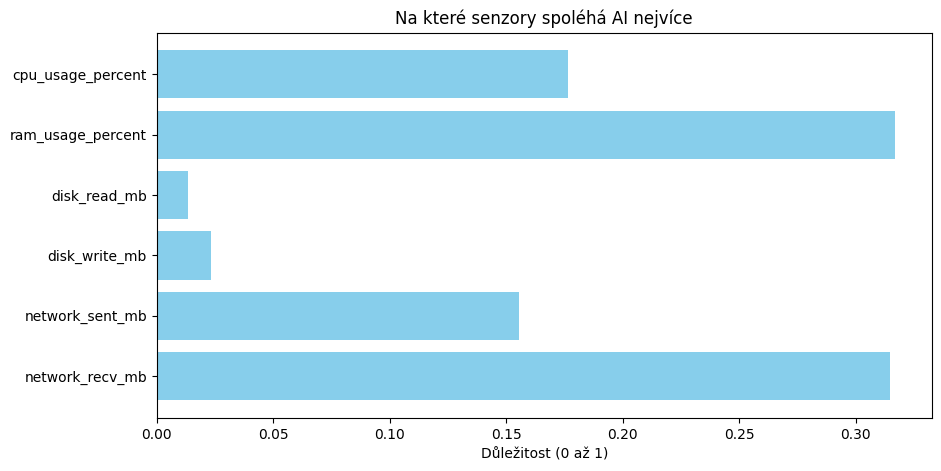

cpu_usage_percent: 17.6 %
ram_usage_percent: 31.7 %
disk_read_mb: 1.3 %
disk_write_mb: 2.3 %
network_sent_mb: 15.5 %
network_recv_mb: 31.5 %


text logic
|--- network_recv_mb <= 0.77
|   |--- network_sent_mb <= -0.66
|   |   |--- ram_usage_percent <= -0.03
|   |   |   |--- class: 0.0
|   |   |--- ram_usage_percent >  -0.03
|   |   |   |--- class: 1.0
|   |--- network_sent_mb >  -0.66
|   |   |--- cpu_usage_percent <= 0.54
|   |   |   |--- cpu_usage_percent <= 0.47
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- cpu_usage_percent >  0.47
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cpu_usage_percent >  0.54
|   |   |   |--- disk_write_mb <= 0.55
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- disk_write_mb >  0.55
|   |   |   |   |--- class: 0.0
|--- network_recv_mb >  0.77
|   |--- network_recv_mb <= 1.11
|   |   |--- ram_usage_percent <= -0.64
|   |   |   |--- network_sent_mb <= 0.84
|   |   |   |   |--- class: 2.0
|   |   |   |--- 

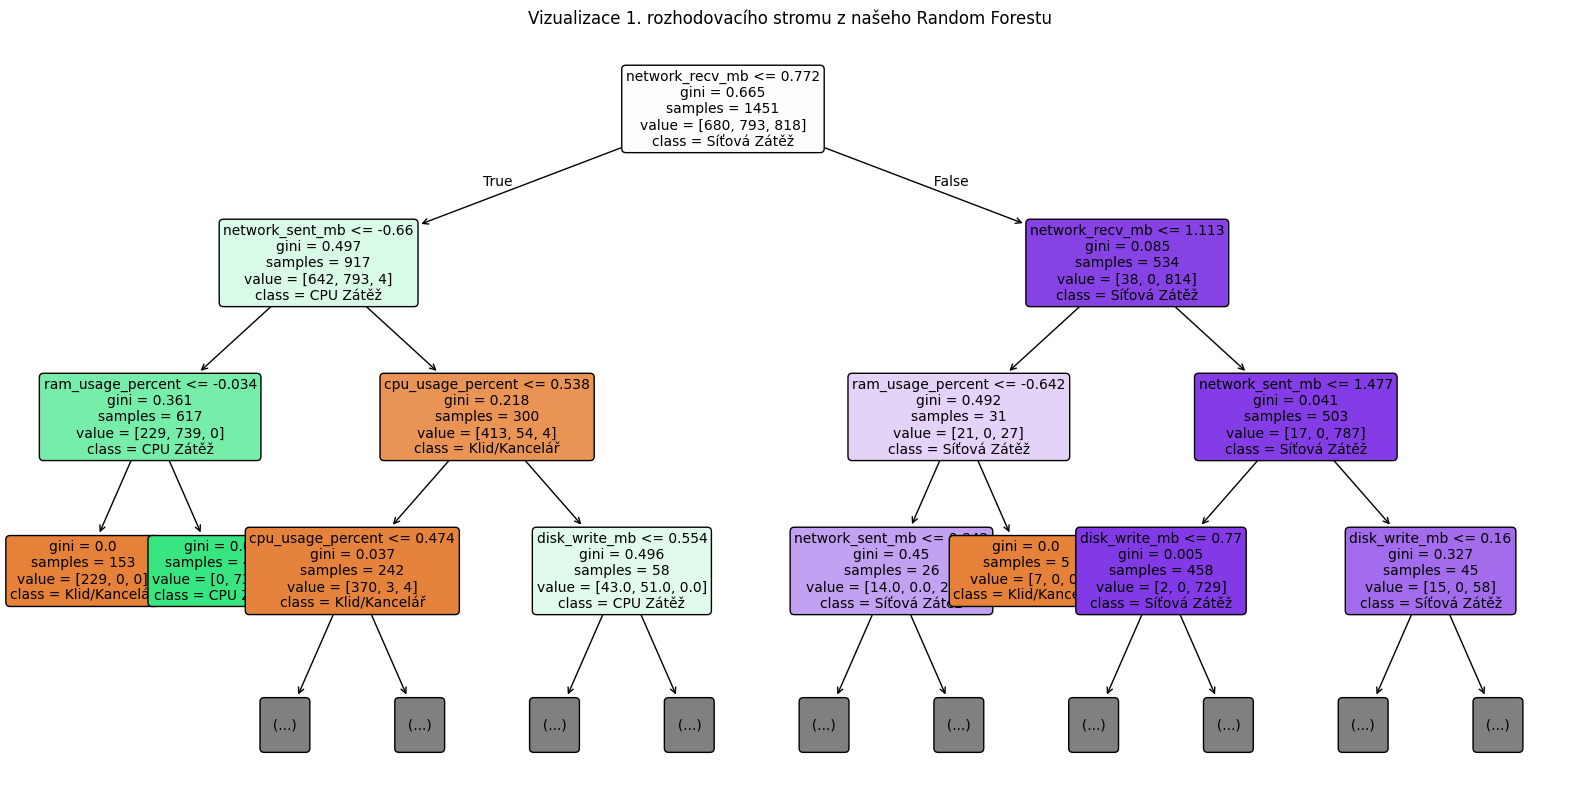

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import export_text, plot_tree
import joblib
import numpy as np

model = joblib.load('telemetry_rf_model.pkl')


rf_model = model.named_steps['rf']

input_features = [
    "cpu_usage_percent", "ram_usage_percent",
    "disk_read_mb", "disk_write_mb",
    "network_sent_mb", "network_recv_mb"
]
class_names = ['Klid/Kancelář', 'CPU Zátěž', 'Síťová Zátěž']


print("significance")
importances = rf_model.feature_importances_

plt.figure(figsize=(10, 5))
plt.barh(input_features, importances, color='skyblue')
plt.xlabel("Důležitost (0 až 1)")
plt.title("Na které senzory spoléhá AI nejvíce")
plt.gca().invert_yaxis()
plt.show()

for feature, imp in zip(input_features, importances):
    print(f"{feature}: {imp*100:.1f} %")
print("\n")



print("text logic")
tree0 = rf_model.estimators_[0]
print(export_text(tree0, feature_names=input_features, max_depth=3))

print("visualization")
plt.figure(figsize=(20, 10))
plot_tree(
    tree0,
    feature_names=input_features,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title("Vizualizace 1. rozhodovacího stromu z našeho Random Forestu")
plt.show()